# Mental Maths Quiz — Performance Analysis

This notebook analyses quiz performance across sessions, levels, and operators.

**Rolling average window:** 5 sessions for all trend lines.

---

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Config ───────────────────────────────────────────────────────────────────
ROLLING_WINDOW = 5
LEVELS         = [1, 2, 3, 4, 5]
OPERATORS      = ['addition', 'subtraction', 'multiplication', 'division', 'percentage']

COLOUR_RT  = '#2196F3'
COLOUR_ACC = '#FF9800'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'font.size': 10,
})

# ── Load questions ────────────────────────────────────────────────────────────
questions = pd.read_csv('questions.csv')
questions['date']             = pd.to_datetime(questions['date'], errors='coerce')
questions['is_correct']       = questions['is_correct'].astype(bool)
questions['response_time_ms'] = pd.to_numeric(questions['response_time_ms'], errors='coerce')
questions['operator']         = questions['operator'].str.strip().str.lower()
questions['difficulty_level'] = pd.to_numeric(questions['difficulty_level'], errors='coerce')
questions.sort_values('date', inplace=True)

# ── Derive sessions from questions (no sessions.csv needed) ───────────────────
sessions = (
    questions
    .groupby('session_id')
    .agg(
        date            = ('date', 'min'),
        level           = ('difficulty_level', 'first'),
        total_questions = ('is_correct', 'count'),
        correct         = ('is_correct', 'sum'),
        avg_response_ms = ('response_time_ms', 'mean'),
    )
    .reset_index()
)
sessions['score_percent'] = round(sessions['correct'] / sessions['total_questions'] * 100, 1)
sessions.sort_values('date', inplace=True)

# ── Merge level onto questions ────────────────────────────────────────────────
questions = questions.merge(
    sessions[['session_id', 'level']].rename(columns={'level': 'session_level'}),
    on='session_id', how='left'
)

print(f"Questions: {len(questions):,} rows")
print(f"Sessions:  {len(sessions):,} rows")
print(f"Levels present:    {sorted(sessions['level'].dropna().unique().tolist())}")
print(f"Operators present: {sorted(questions['operator'].dropna().unique().tolist())}")



Questions: 335 rows
Sessions:  16 rows
Levels present:    [1, 2, 3, 4, 5]
Operators present: ['addition', 'division', 'multiplication', 'percentage', 'subtraction']


## Load & Prepare Data

Questions: 259 rows
Sessions:  12 rows
Levels present:    [1, 2, 3, 4, 5]
Operators present: ['addition', 'division', 'multiplication', 'percentage', 'subtraction']


---
## Graph 1 — Level Comparison (static snapshot)

Single chart: average response time (left axis, blue) and accuracy rate (right axis, amber) per level.

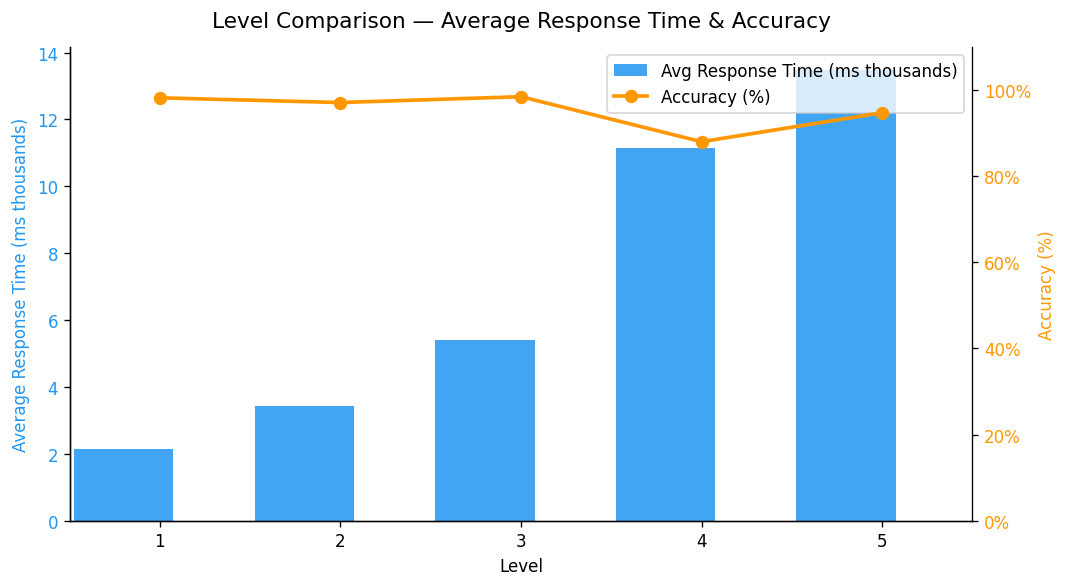

In [8]:
level_stats = (
    questions
    .groupby('session_level')
    .agg(
        avg_rt   = ('response_time_ms', 'mean'),
        accuracy = ('is_correct',       'mean'),
    )
    .reindex(LEVELS)
    .reset_index()
    .rename(columns={'session_level': 'level'})
)

# Convert ms to thousands
level_stats['avg_rt_k'] = level_stats['avg_rt'] / 1000

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

x = level_stats['level']

bars = ax1.bar(x - 0.2, level_stats['avg_rt_k'], width=0.55,
               color=COLOUR_RT, alpha=0.85, label='Avg Response Time (ms thousands)')
line = ax2.plot(x, level_stats['accuracy'] * 100, 'o-',
                color=COLOUR_ACC, linewidth=2.2, markersize=7,
                label='Accuracy (%)')

ax1.set_xlabel('Level')
ax1.set_ylabel('Average Response Time (ms thousands)', color=COLOUR_RT)
ax2.set_ylabel('Accuracy (%)',                     color=COLOUR_ACC)
ax1.tick_params(axis='y', labelcolor=COLOUR_RT)
ax2.tick_params(axis='y', labelcolor=COLOUR_ACC)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.set_ylim(0, 110)
ax1.set_xticks(LEVELS)
ax1.set_xlim(0.5, 5.5)
ax1.spines['right'].set_visible(False)

# Combined legend
handles = [bars, line[0]]
ax1.legend(handles, [h.get_label() for h in handles],
           loc='upper right', framealpha=0.8)

plt.title('Level Comparison — Average Response Time & Accuracy', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

---
## Graph 2 — Development Overview (one graph per level)

5 graphs. X axis = cumulative session number at that level. Dual Y: rolling-5 avg response time (blue) and rolling-5 accuracy (amber).

Plotting levels: [3]


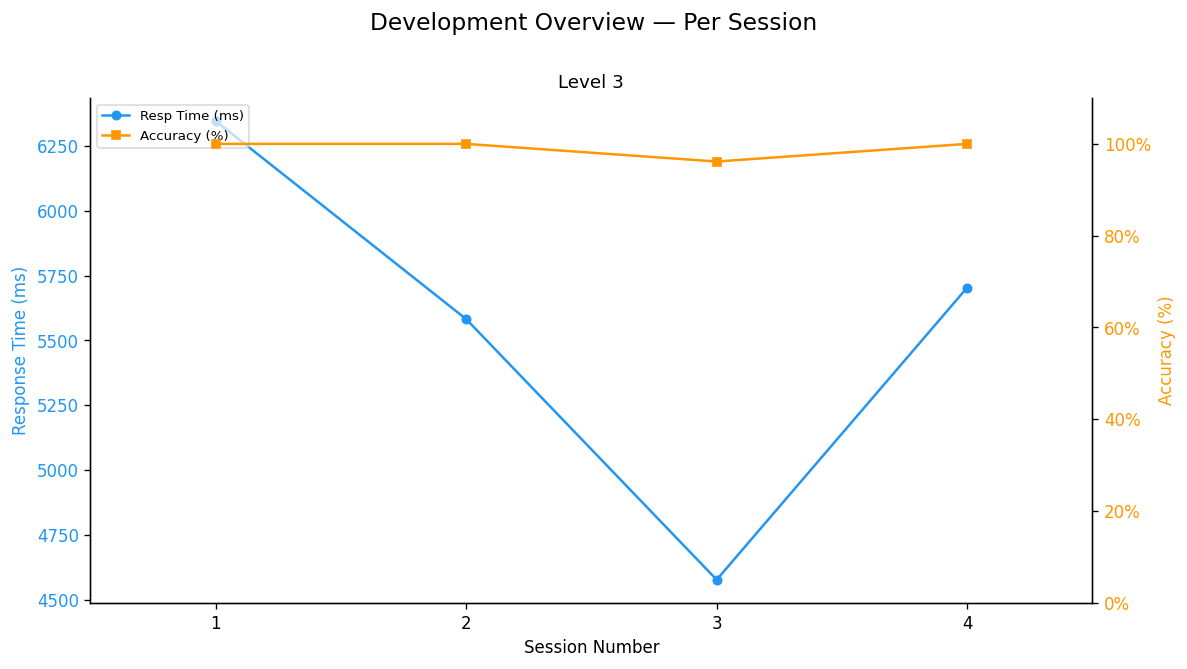

In [16]:
def build_session_series(df_q, level):
    """
    Aggregate all questions at a given level → per-session stats.
    session_num is based on chronological position within that level.
    """
    level_mask = df_q['session_level'] == level
    subset = df_q[level_mask].copy()

    if subset.empty:
        return pd.DataFrame()

    grp = (
        subset
        .groupby('session_id')
        .agg(
            date     = ('date', 'min'),
            avg_rt   = ('response_time_ms', 'mean'),
            accuracy = ('is_correct', 'mean'),
        )
        .reset_index()
        .sort_values('date')
        .reset_index(drop=True)
    )
    grp['session_num'] = range(1, len(grp) + 1)
    return grp


def plot_dual_trend(ax1, series, title):
    """Draw per-session RT + accuracy on a dual-axis chart."""
    if series.empty:
        ax1.text(0.5, 0.5, 'No data', transform=ax1.transAxes,
                 ha='center', va='center', color='grey')
        ax1.set_title(title); return

    ax2 = ax1.twinx()
    x   = series['session_num']

    ax1.plot(x, series['avg_rt'], 'o-', color=COLOUR_RT,
             linewidth=1.5, markersize=5, label='Resp Time (ms)')

    ax2.plot(x, series['accuracy'] * 100, 's-', color=COLOUR_ACC,
             linewidth=1.5, markersize=5, label='Accuracy (%)')

    ax1.set_ylabel('Response Time (ms)', color=COLOUR_RT)
    ax2.set_ylabel('Accuracy (%)',        color=COLOUR_ACC)
    ax1.tick_params(axis='y', labelcolor=COLOUR_RT)
    ax2.tick_params(axis='y', labelcolor=COLOUR_ACC)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax2.set_ylim(0, 110)

    total_sessions = x.max()
    ax1.set_xticks(range(1, total_sessions + 1))
    ax1.set_xlim(0.5, total_sessions + 0.5)

    ax1.set_xlabel('Session Number')
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.set_title(title, fontsize=11)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8, framealpha=0.7)


# ── Prompt for levels ─────────────────────────────────────────────────────────
raw = input(f"Enter level(s) to plot {LEVELS} — separate multiple with commas: ")

selected_levels = []
for token in raw.split(','):
    token = token.strip()
    try:
        lvl = int(token)
        if lvl in LEVELS:
            selected_levels.append(lvl)
        else:
            print(f"  Skipping {lvl!r} — not a valid level (choose from {LEVELS})")
    except ValueError:
        print(f"  Skipping {token!r} — not a number")

if not selected_levels:
    print("No valid levels entered. Nothing to plot.")
else:
    print(f"Plotting levels: {selected_levels}")
    n = len(selected_levels)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5.5 * n))
    if n == 1:
        axes = [axes]

    fig.suptitle('Development Overview — Per Session', fontsize=14, y=1.005)

    for ax, lvl in zip(axes, selected_levels):
        series = build_session_series(questions, level=lvl)
        plot_dual_trend(ax, series, f'Level {lvl}')

    plt.tight_layout(h_pad=3)
    plt.show()



---
## Graph 3 — Operator Development (5 operators × 5 levels = 25 graphs)

Arranged as a 5×5 grid (rows = levels 1-5, columns = operators). Same dual-axis rolling format as Graph 2.


Data check:
  Level 3 |       addition: 4 session(s), at positions [1, 2, 3, 4]
  Level 3 |    subtraction: 4 session(s), at positions [1, 2, 3, 4]
  Level 3 | multiplication: 4 session(s), at positions [1, 2, 3, 4]
  Level 3 |       division: 4 session(s), at positions [1, 2, 3, 4]
  Level 3 |     percentage: 4 session(s), at positions [1, 2, 3, 4]



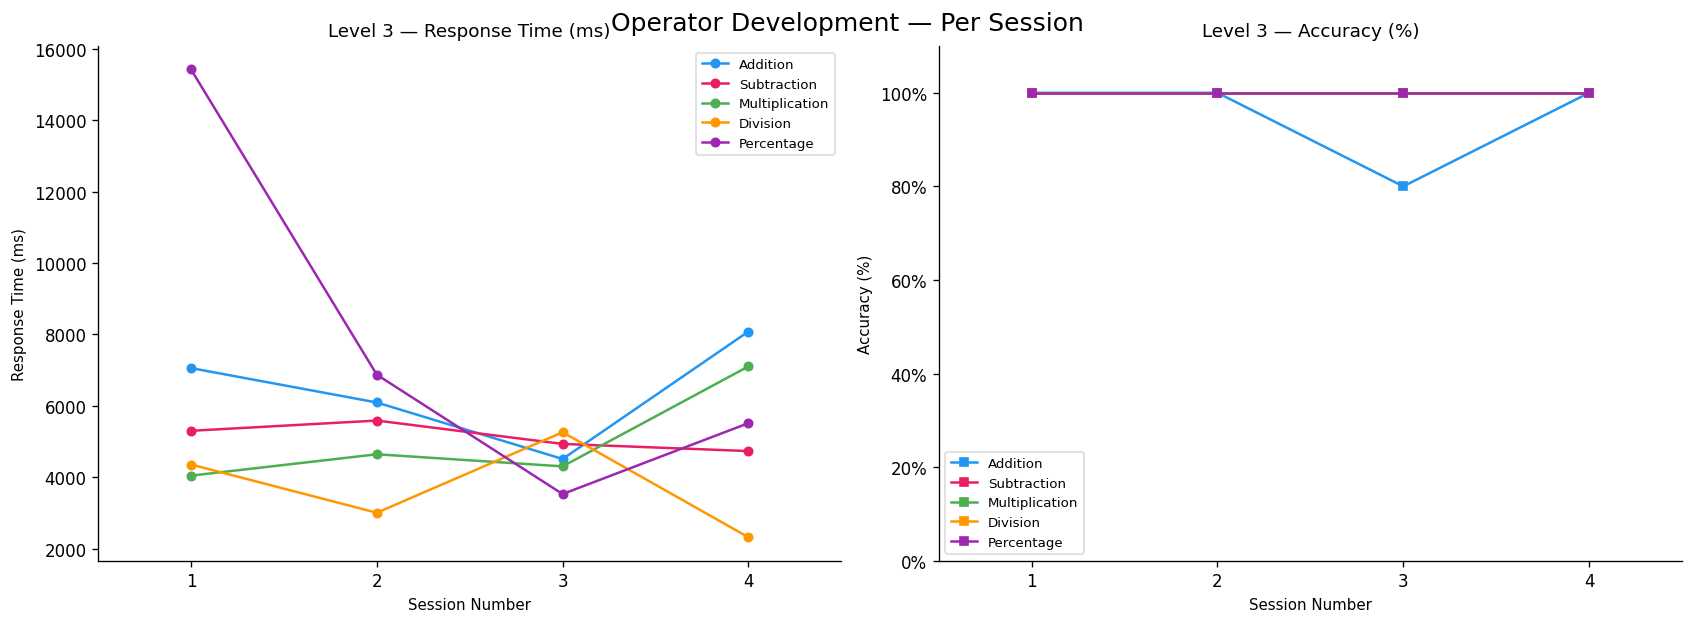

In [17]:
op_labels = {
    'addition':       'Addition',
    'subtraction':    'Subtraction',
    'multiplication': 'Multiplication',
    'division':       'Division',
    'percentage':     'Percentage',
}

OP_COLOURS = {
    'addition':       '#2196F3',
    'subtraction':    '#E91E63',
    'multiplication': '#4CAF50',
    'division':       '#FF9800',
    'percentage':     '#9C27B0',
}

def build_operator_series(df_q, level, operator):
    # Step 1: all sessions at this level in chronological order
    level_mask = df_q['session_level'] == level
    level_sessions = (
        df_q[level_mask]
        .groupby('session_id')
        .agg(date=('date', 'min'))
        .reset_index()
        .sort_values('date')
        .reset_index(drop=True)
    )
    level_sessions['session_num'] = range(1, len(level_sessions) + 1)
    session_num_map = level_sessions.set_index('session_id')['session_num']

    # Step 2: filter to this operator within that level
    op_mask = level_mask & (df_q['operator'] == operator)
    subset  = df_q[op_mask].copy()

    if subset.empty:
        return pd.DataFrame()

    # Step 3: aggregate and map session_num from the level-wide ordering
    grp = (
        subset
        .groupby('session_id')
        .agg(
            avg_rt   = ('response_time_ms', 'mean'),
            accuracy = ('is_correct', 'mean'),
        )
        .reset_index()
    )
    grp['session_num'] = grp['session_id'].map(session_num_map)
    grp = grp.sort_values('session_num').reset_index(drop=True)
    return grp


# ── Prompt for levels ─────────────────────────────────────────────────────────
raw = input(f"Enter level(s) to plot {LEVELS} — separate multiple with commas: ")

selected_levels = []
for token in raw.split(','):
    token = token.strip()
    try:
        lvl = int(token)
        if lvl in LEVELS:
            selected_levels.append(lvl)
        else:
            print(f"  Skipping {lvl!r} — not a valid level (choose from {LEVELS})")
    except ValueError:
        print(f"  Skipping {token!r} — not a number")

if not selected_levels:
    print("No valid levels entered. Nothing to plot.")
else:
    # ── Debug: show session counts per operator for selected levels ───────────
    print("\nData check:")
    for lvl in selected_levels:
        for op in OPERATORS:
            s = build_operator_series(questions, level=lvl, operator=op)
            print(f"  Level {lvl} | {op:>14}: {len(s)} session(s), at positions {s['session_num'].tolist()}")

    print()
    n = len(selected_levels)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=2,
        figsize=(14, 5 * n),
        constrained_layout=True,
    )

    if n == 1:
        axes = [axes]

    fig.suptitle('Operator Development — Per Session', fontsize=15, y=1.01)

    for row, lvl in enumerate(selected_levels):
        ax_rt  = axes[row][0]
        ax_acc = axes[row][1]

        ax_rt.set_title(f'Level {lvl} — Response Time (ms)', fontsize=11)
        ax_acc.set_title(f'Level {lvl} — Accuracy (%)',       fontsize=11)

        # Total sessions at this level sets the x range
        total_sessions = len(
            questions[questions['session_level'] == lvl]['session_id'].unique()
        )

        for op in OPERATORS:
            series = build_operator_series(questions, level=lvl, operator=op)
            if series.empty:
                continue

            colour = OP_COLOURS[op]
            label  = op_labels[op]
            x      = series['session_num']

            ax_rt.plot(x, series['avg_rt'], 'o-',
                       color=colour, linewidth=1.5, markersize=5, label=label)
            ax_acc.plot(x, series['accuracy'] * 100, 's-',
                        color=colour, linewidth=1.5, markersize=5, label=label)

        ticks = range(1, total_sessions + 1)
        for ax in [ax_rt, ax_acc]:
            ax.set_xticks(ticks)
            ax.set_xlim(0.5, total_sessions + 0.5)

        ax_rt.set_xlabel('Session Number', fontsize=9)
        ax_rt.set_ylabel('Response Time (ms)', fontsize=9)
        ax_rt.spines['top'].set_visible(False)
        ax_rt.spines['right'].set_visible(False)
        ax_rt.legend(fontsize=8, framealpha=0.7)

        ax_acc.set_xlabel('Session Number', fontsize=9)
        ax_acc.set_ylabel('Accuracy (%)', fontsize=9)
        ax_acc.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
        ax_acc.set_ylim(0, 110)
        ax_acc.spines['top'].set_visible(False)
        ax_acc.spines['right'].set_visible(False)
        ax_acc.legend(fontsize=8, framealpha=0.7)

    plt.show()

